In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input, UpSampling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, VotingClassifier
from skimage.feature import hog
from skimage.color import rgb2gray
import warnings
warnings.filterwarnings('ignore')

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [3]:
(X_train_orig, y_train_orig), (X_test_orig, y_test_orig) = cifar10.load_data()
X_full = np.concatenate((X_train_orig, X_test_orig), axis=0)
y_full = np.concatenate((y_train_orig, y_test_orig), axis=0).flatten()
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

print("Loaded CIFAR-10 dataset")
print("Full dataset shape:", X_full.shape)
print("Unique labels:", np.unique(y_full))
print("Class count:")
print(pd.Series(y_full).value_counts().sort_index())

sample_size = 12000
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_full), sample_size, replace=False)
X = X_full[sample_idx]
y = y_full[sample_idx]

print("Using sample size:", X.shape)

Loaded CIFAR-10 dataset
Full dataset shape: (60000, 32, 32, 3)
Unique labels: [0 1 2 3 4 5 6 7 8 9]
Class count:
0    6000
1    6000
2    6000
3    6000
4    6000
5    6000
6    6000
7    6000
8    6000
9    6000
Name: count, dtype: int64
Using sample size: (12000, 32, 32, 3)


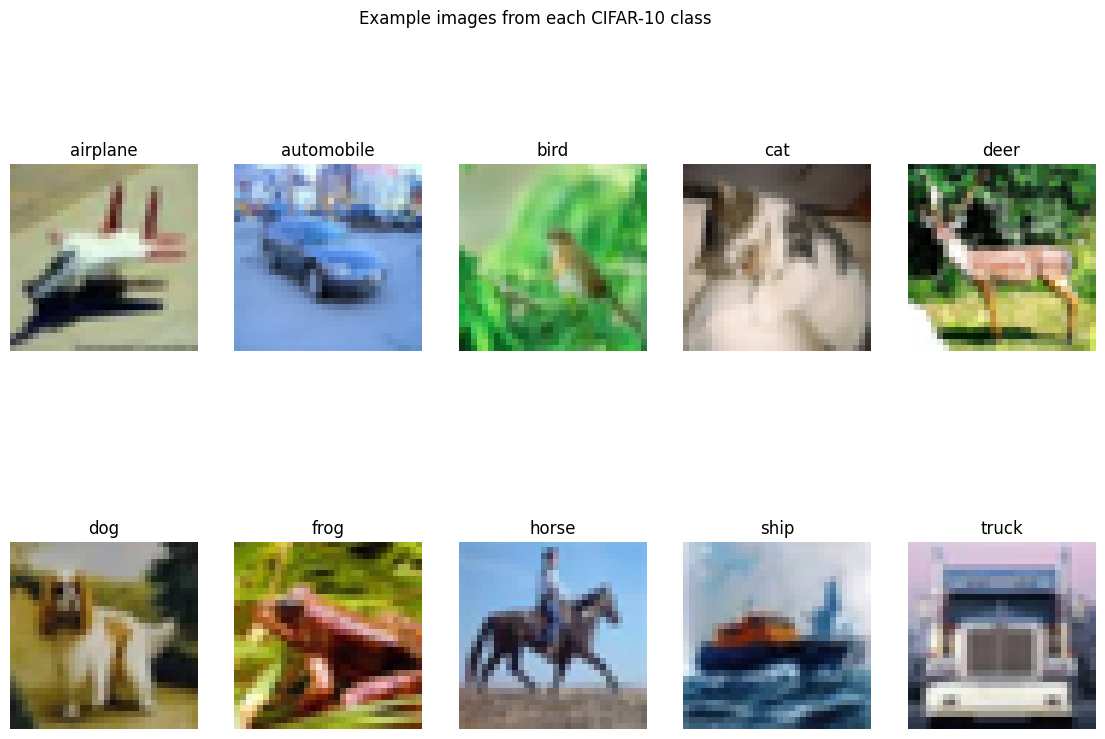

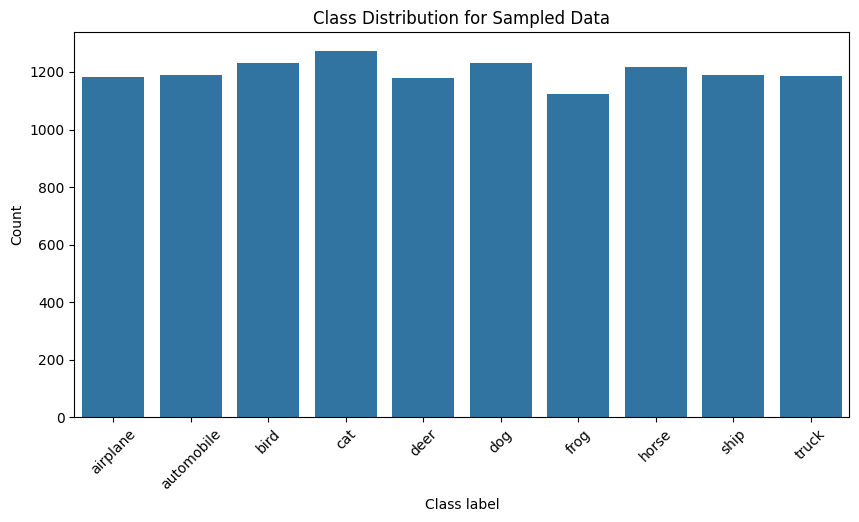

Pixel value range: 0.0 1.0
Per-channel mean: [0.4922244 0.481917  0.4455828]
Per-channel std: [0.2472198  0.24374154 0.26133972]


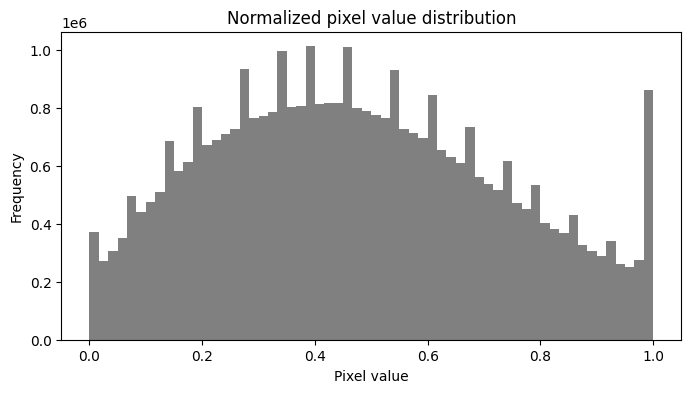

In [4]:
plt.figure(figsize=(14, 9))
for i in range(10):
    idx = np.where(y == i)[0][0]
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[idx])
    plt.title(classes[i])
    plt.axis('off')
plt.suptitle('Example images from each CIFAR-10 class')
plt.show()

plt.figure(figsize=(10, 5))
sns.countplot(x=y)
plt.title('Class Distribution for Sampled Data')
plt.xlabel('Class label')
plt.ylabel('Count')
plt.xticks(ticks=np.arange(10), labels=classes, rotation=45)
plt.show()

X_norm = X.astype('float32') / 255.0
print('Pixel value range:', X_norm.min(), X_norm.max())
print('Per-channel mean:', X_norm.mean(axis=(0,1,2)))
print('Per-channel std:', X_norm.std(axis=(0,1,2)))

plt.figure(figsize=(8, 4))
plt.hist(X_norm.ravel(), bins=60, color='gray')
plt.title('Normalized pixel value distribution')
plt.xlabel('Pixel value')
plt.ylabel('Frequency')
plt.show()

In [5]:
def extract_hog_features(images, pixels_per_cell=(8, 8), cells_per_block=(2, 2)):
    features = []
    for img in images:
        gray = rgb2gray(img)
        features.append(hog(gray, pixels_per_cell=pixels_per_cell, cells_per_block=cells_per_block, feature_vector=True))
    return np.array(features)

X_hog = extract_hog_features(X)
print('HOG feature shape:', X_hog.shape)

scaler = StandardScaler()
X_hog_scaled = scaler.fit_transform(X_hog)

X_train, X_test, y_train, y_test = train_test_split(X_hog_scaled, y, test_size=0.2, stratify=y, random_state=42)
print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

HOG feature shape: (12000, 324)
Train shape: (9600, 324) Test shape: (2400, 324)


In [6]:
param_grid_knn = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance']
}
knn_grid = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=3, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train, y_train)
print('Best KNN params:', knn_grid.best_params_)

nb_grid = GridSearchCV(GaussianNB(), {'var_smoothing': [1e-9, 1e-8, 1e-7]}, cv=3, scoring='accuracy', n_jobs=-1)
nb_grid.fit(X_train, y_train)
print('Best NB params:', nb_grid.best_params_)

knn_best = knn_grid.best_estimator_
nb_best = nb_grid.best_estimator_

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

ada = AdaBoostClassifier(n_estimators=80, random_state=42)
ada.fit(X_train, y_train)

voting = VotingClassifier(estimators=[('knn', knn_best), ('rf', rf), ('ada', ada)], voting='soft')
voting.fit(X_train, y_train)

Best KNN params: {'n_neighbors': 7, 'weights': 'distance'}
Best NB params: {'var_smoothing': 1e-09}


VotingClassifier(estimators=[('knn',
                              KNeighborsClassifier(n_neighbors=7,
                                                   weights='distance')),
                             ('rf', RandomForestClassifier(random_state=42)),
                             ('ada',
                              AdaBoostClassifier(n_estimators=80,
                                                 random_state=42))],
                 voting='soft')

In [7]:
models = [
    ('KNN', knn_best),
    ('Naive Bayes', nb_best),
    ('Random Forest', rf),
    ('AdaBoost', ada),
    ('Voting', voting)
]

results = []
for name, model in models:
    y_pred = model.predict(X_test)
    results.append((name,
                    accuracy_score(y_test, y_pred),
                    f1_score(y_test, y_pred, average='weighted')))

results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Weighted F1'])
print(results_df)

best_model_name, best_accuracy, _ = results[0]
for name, acc, _ in results:
    if acc > best_accuracy:
        best_model_name = name
        best_accuracy = acc

print(f"Best classical model: {best_model_name} (accuracy={best_accuracy:.4f})")

           Model  Accuracy  Weighted F1
0            KNN  0.435833     0.436231
1    Naive Bayes  0.448333     0.443022
2  Random Forest  0.463750     0.461775
3       AdaBoost  0.297917     0.296832
4         Voting  0.476250     0.476389
Best classical model: Voting (accuracy=0.4763)


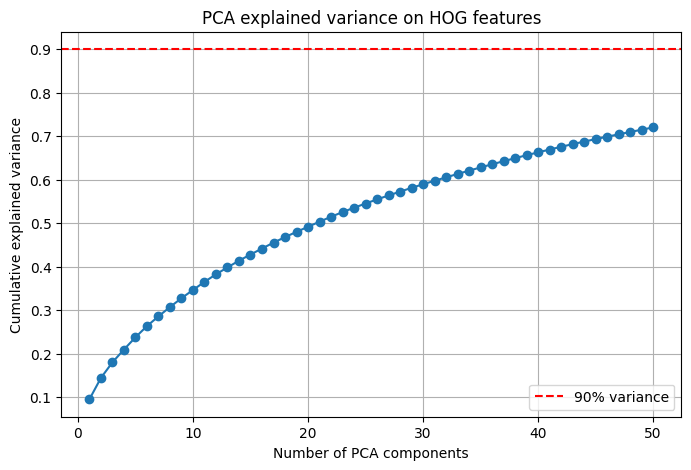

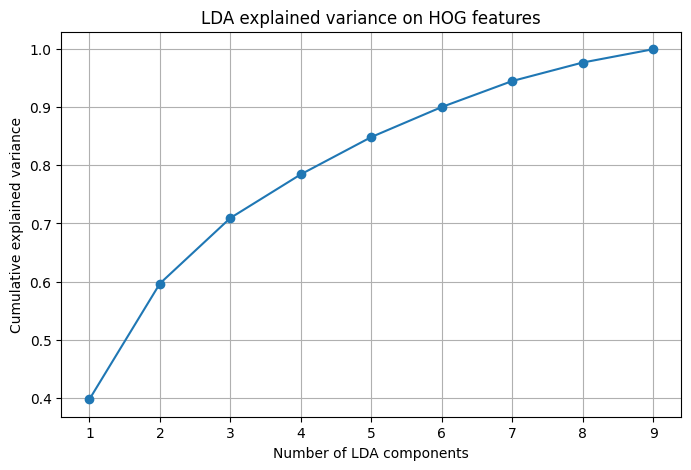

In [8]:
pca = PCA(n_components=50, random_state=42)
pca.fit(X_train)
explained = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(explained)+1), explained, marker='o')
plt.xlabel('Number of PCA components')
plt.ylabel('Cumulative explained variance')
plt.title('PCA explained variance on HOG features')
plt.grid(True)
plt.axhline(0.90, linestyle='--', color='red', label='90% variance')
plt.legend()
plt.show()

lda = LDA(n_components=9)
lda.fit(X_train, y_train)
lda_explained = np.cumsum(lda.explained_variance_ratio_)
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(lda_explained)+1), lda_explained, marker='o')
plt.xlabel('Number of LDA components')
plt.ylabel('Cumulative explained variance')
plt.title('LDA explained variance on HOG features')
plt.grid(True)
plt.show()

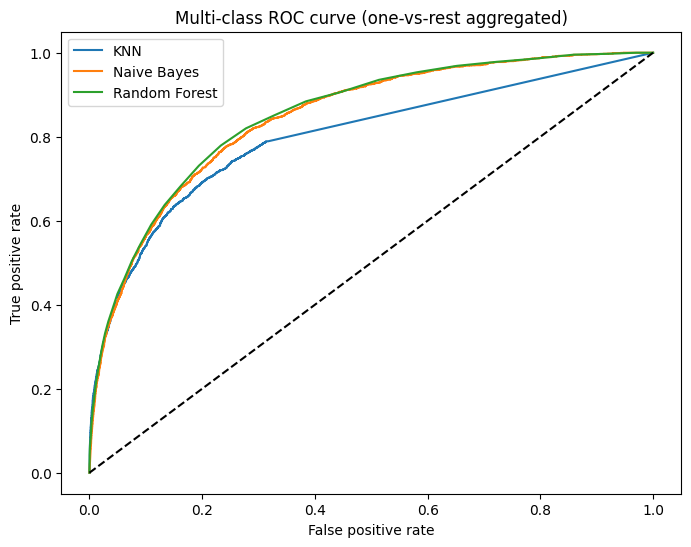

Classification report for best model: Voting
              precision    recall  f1-score   support

    airplane       0.70      0.44      0.54       236
  automobile       0.69      0.60      0.64       238
        bird       0.55      0.30      0.39       246
         cat       0.47      0.19      0.27       255
        deer       0.28      0.52      0.36       236
         dog       0.44      0.38      0.41       246
        frog       0.33      0.74      0.46       225
       horse       0.66      0.45      0.54       243
        ship       0.60      0.61      0.61       238
       truck       0.57      0.58      0.57       237

    accuracy                           0.48      2400
   macro avg       0.53      0.48      0.48      2400
weighted avg       0.53      0.48      0.48      2400



In [9]:
y_test_bin = label_binarize(y_test, classes=np.arange(10))
plt.figure(figsize=(8, 6))
for model, label in [(knn_best, 'KNN'), (nb_best, 'Naive Bayes'), (rf, 'Random Forest')]:
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)
        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
        plt.plot(fpr, tpr, label=label)

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Multi-class ROC curve (one-vs-rest aggregated)')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.legend()
plt.show()

print('Classification report for best model:', best_model_name)
print(classification_report(y_test, voting.predict(X_test), target_names=classes))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 592,170 (2.26 MB)

 Trainable params: 591,722 (2.26 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/10
319/319 - 21s - 66ms/step - accuracy: 0.4554 - loss: 1.5682 - val_accuracy: 0.1135 - val_loss: 3.2671
Epoch 2/10
319/319 - 4s - 12ms/step - accuracy: 0.6039 - loss: 1.1159 - val_accuracy: 0.6349 - val_loss: 1.0297
Epoch 3/10
319/319 - 4s - 11ms/step - accuracy: 0.6670 - loss: 0.9500 - val_accuracy: 0.6787 - val_loss: 0.9076
Epoch 4/10
319/319 - 4s - 11ms/step - accuracy: 0.7023 - loss: 0.8549 - val_accuracy: 0.7039 - val_loss: 0.8471
Epoch 5/10
319/319 - 4s - 12ms/step - accuracy: 0.7262 - loss: 0.7846 - val_accuracy: 0.7097 - val_loss: 0.8338
Epoch 6/10
319/319 - 4s - 11ms/step - accuracy: 0.7435 - loss: 0.7329 - val_accuracy: 0.7508 - val_loss: 0.7193
Epoch 7/10
319/319 - 4s - 11ms/step - accuracy: 0.7572 - loss: 0.6921 - val_accuracy: 0.7387 - val_loss: 0.7392
Epoch 8/10
319/319 - 5s - 17ms/step - accuracy: 0.7697 - loss: 0.6596 - val_accuracy: 0.7247 - val_loss: 0.8124
Epoch 9/10
319/319 - 4s - 11ms/step - accuracy: 0.7827 - loss: 0.6233 - val_accuracy: 0.7799 - val_loss

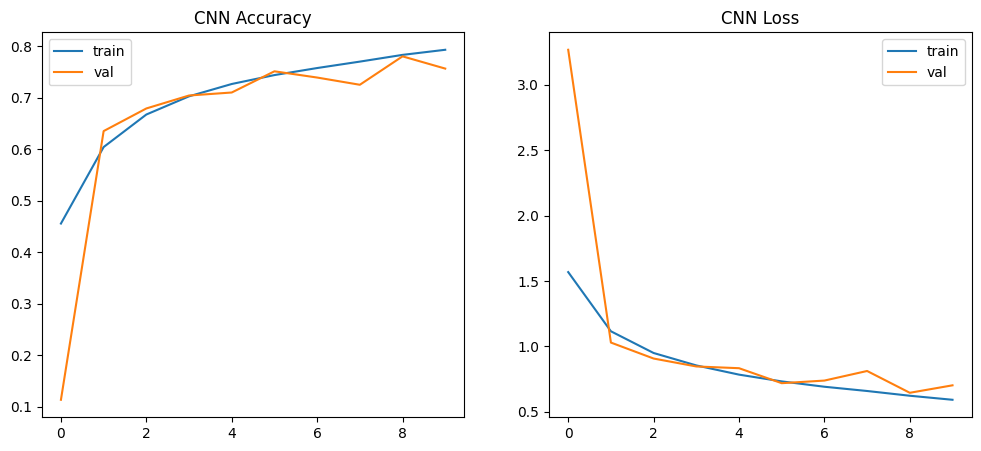

CNN test loss/accuracy: [0.6686640977859497, 0.7705000042915344]


In [10]:
# Phase 2: CNN and Transfer Learning
X_dl = X_full.astype('float32') / 255.0
y_dl = to_categorical(y_full, num_classes=10)

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(X_dl, y_dl, test_size=0.2, stratify=y_full, random_state=42)

model_cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Flatten(),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(10, activation='softmax')
])

model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_cnn.summary()

history_cnn = model_cnn.fit(
    X_train_dl, y_train_dl,
    validation_split=0.15,
    epochs=10,
    batch_size=128,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)],
    verbose=2
)

train_acc = history_cnn.history['accuracy']
val_acc = history_cnn.history['val_accuracy']
train_loss = history_cnn.history['loss']
val_loss = history_cnn.history['val_loss']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_acc, label='train')
plt.plot(val_acc, label='val')
plt.title('CNN Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_loss, label='train')
plt.plot(val_loss, label='val')
plt.title('CNN Loss')
plt.legend()
plt.show()

cnn_eval = model_cnn.evaluate(X_test_dl, y_test_dl, verbose=0)
print('CNN test loss/accuracy:', cnn_eval)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 3)      │         1,731 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,299 (262.89 KB)

 Trainable params: 67,299 (262.89 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
319/319 - 11s - 34ms/step - loss: 0.0133 - val_loss: 0.0086
Epoch 2/8
319/319 - 3s - 10ms/step - loss: 0.0081 - val_loss: 0.0075
Epoch 3/8
319/319 - 3s - 10ms/step - loss: 0.0073 - val_loss: 0.0072
Epoch 4/8
319/319 - 4s - 11ms/step - loss: 0.0068 - val_loss: 0.0065
Epoch 5/8
319/319 - 3s - 10ms/step - loss: 0.0065 - val_loss: 0.0062
Epoch 6/8
319/319 - 3s - 10ms/step - loss: 0.0062 - val_loss: 0.0061
Epoch 7/8
319/319 - 3s - 10ms/step - loss: 0.0061 - val_loss: 0.0060
Epoch 8/8
319/319 - 4s - 11ms/step - loss: 0.0059 - val_loss: 0.0058
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 613ms/step


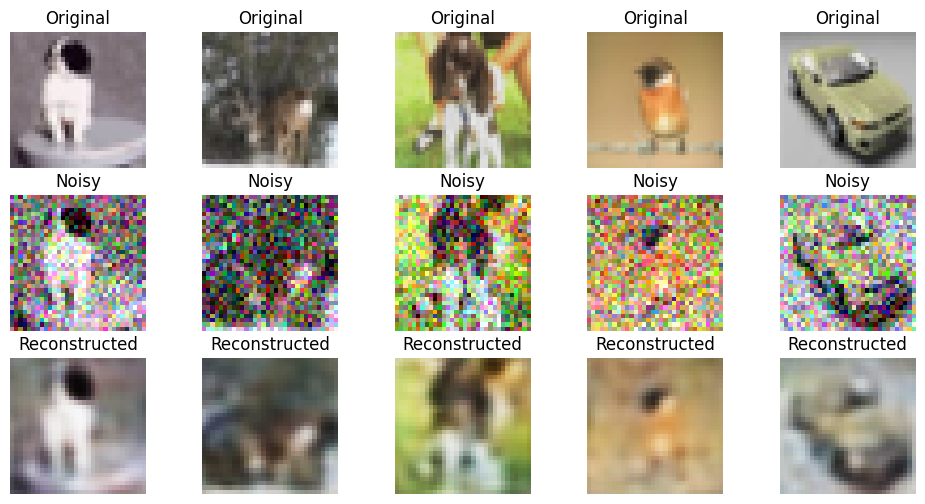

In [11]:
# Phase 2: Autoencoder for image reconstruction
noise_factor = 0.2
X_train_noisy = np.clip(X_train_dl + noise_factor * np.random.normal(size=X_train_dl.shape), 0., 1.)
X_test_noisy = np.clip(X_test_dl + noise_factor * np.random.normal(size=X_test_dl.shape), 0., 1.)

input_img = Input(shape=(32, 32, 3))

x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)

decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

autoencoder.fit(X_train_noisy, X_train_dl,
                epochs=8,
                batch_size=128,
                shuffle=True,
                validation_split=0.15,
                verbose=2)

reconstructed = autoencoder.predict(X_test_noisy[:10])
plt.figure(figsize=(12, 6))
for i in range(5):
    plt.subplot(3, 5, i + 1)
    plt.imshow(X_test_dl[i])
    plt.title('Original')
    plt.axis('off')
    plt.subplot(3, 5, i + 6)
    plt.imshow(X_test_noisy[i])
    plt.title('Noisy')
    plt.axis('off')
    plt.subplot(3, 5, i + 11)
    plt.imshow(reconstructed[i])
    plt.title('Reconstructed')
    plt.axis('off')
plt.show()

X_tl shape: (4000, 32, 32, 3) range: 0.0 255.0
X_resized shape: (4000, 96, 96, 3) range: 0.0 255.0
train shapes: (3000, 96, 96, 3) (3000, 10) test shapes: (1000, 96, 96, 3) (1000, 10)
unique y_train one-hot counts: (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]), array([316, 289, 287, 310, 286, 313, 277, 316, 304, 302]))


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_0.35_96             │ (None, 1280)           │       410,208 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 492,842 (1.88 MB)

 Trainable params: 82,634 (322.79 KB)

 Non-trainable params: 410,208 (1.56 MB)

Epoch 1/4
80/80 - 20s - 247ms/step - accuracy: 0.5208 - loss: 1.4118 - val_accuracy: 0.6644 - val_loss: 0.9809
Epoch 2/4
80/80 - 1s - 16ms/step - accuracy: 0.7345 - loss: 0.7801 - val_accuracy: 0.6933 - val_loss: 0.8460
Epoch 3/4
80/80 - 1s - 14ms/step - accuracy: 0.7882 - loss: 0.6224 - val_accuracy: 0.7222 - val_loss: 0.7909
Epoch 4/4
80/80 - 1s - 11ms/step - accuracy: 0.8271 - loss: 0.5134 - val_accuracy: 0.7178 - val_loss: 0.7839
Transfer learning model test loss/accuracy: [0.6227590441703796, 0.7910000085830688]
Epoch 1/2
80/80 - 34s - 426ms/step - accuracy: 0.7306 - loss: 0.7908 - val_accuracy: 0.7111 - val_loss: 0.7968
Epoch 2/2
80/80 - 1s - 13ms/step - accuracy: 0.7663 - loss: 0.6965 - val_accuracy: 0.7089 - val_loss: 0.8149
Fine-tuned transfer model test loss/accuracy: [0.630234956741333, 0.7879999876022339]


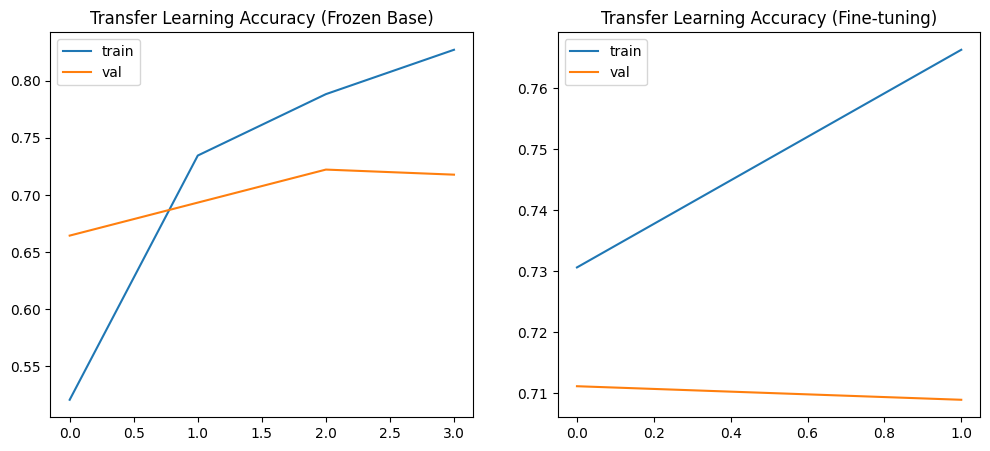

In [5]:
# Phase 2: Transfer learning using MobileNetV2
sample_idx = np.random.RandomState(42).choice(len(X_full), 4000, replace=False)
X_tl = X_full[sample_idx].astype('float32')
y_tl = y_full[sample_idx]

X_resized = tf.image.resize(X_tl, (96, 96)).numpy()
y_tl_cat = to_categorical(y_tl, 10)
X_train_tl, X_test_tl, y_train_tl, y_test_tl = train_test_split(
    X_resized, y_tl_cat, test_size=0.25, stratify=y_tl, random_state=42)

print('X_tl shape:', X_tl.shape, 'range:', X_tl.min(), X_tl.max())
print('X_resized shape:', X_resized.shape, 'range:', X_resized.min(), X_resized.max())
print('train shapes:', X_train_tl.shape, y_train_tl.shape, 'test shapes:', X_test_tl.shape, y_test_tl.shape)
print('unique y_train one-hot counts:', np.unique(np.argmax(y_train_tl, axis=1), return_counts=True))

try:
    base_model = MobileNetV2(alpha=0.35, include_top=False, weights='imagenet', input_shape=(96, 96, 3), pooling='avg')
except Exception as exc:
    print('Pretrained weights unavailable, loading untrained MobileNetV2:', exc)
    base_model = MobileNetV2(alpha=0.35, include_top=False, weights=None, input_shape=(96, 96, 3), pooling='avg')

base_model.trainable = False
inputs = Input(shape=(96, 96, 3))
x = mobilenet_preprocess(inputs)
x = base_model(x, training=False)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(10, activation='softmax')(x)
transfer_model = Model(inputs, outputs)
transfer_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
transfer_model.summary()

history_tl = transfer_model.fit(
    X_train_tl, y_train_tl,
    validation_split=0.15,
    epochs=4,
    batch_size=32,
    callbacks=[EarlyStopping(patience=2, restore_best_weights=True)],
    verbose=2
)

transfer_eval = transfer_model.evaluate(X_test_tl, y_test_tl, verbose=0)
print('Transfer learning model test loss/accuracy:', transfer_eval)

# Fine-tune last layers
base_model.trainable = True
for layer in base_model.layers[:-40]:
    layer.trainable = False

transfer_model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
history_tl_ft = transfer_model.fit(
    X_train_tl, y_train_tl,
    validation_split=0.15,
    epochs=2,
    batch_size=32,
    callbacks=[EarlyStopping(patience=1, restore_best_weights=True)],
    verbose=2
)

transfer_ft_eval = transfer_model.evaluate(X_test_tl, y_test_tl, verbose=0)
print('Fine-tuned transfer model test loss/accuracy:', transfer_ft_eval)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_tl.history['accuracy'], label='train')
plt.plot(history_tl.history['val_accuracy'], label='val')
plt.title('Transfer Learning Accuracy (Frozen Base)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_tl_ft.history['accuracy'], label='train')
plt.plot(history_tl_ft.history['val_accuracy'], label='val')
plt.title('Transfer Learning Accuracy (Fine-tuning)')
plt.legend()
plt.show()
